In [ ]:
import pandas as pd
df = pd.read_csv("Nike_Sales_Uncleaned.csv")
df.head()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89


In [ ]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB


,Order_ID,Units_Sold,MRP,Discount_Applied,Revenue,Profit
count,2500.000000,1265.000000,1246.000000,832.000000,2500.000000,2500.000000
mean,3194.352400,1.482213,6039.863395,0.631022,274.873716,1376.012848
std,749.972638,1.696947,2315.746826,0.365500,2023.773550,1478.671013
min,2000.000000,-1.000000,2006.630000,0.000000,-7561.590000,-1199.450000
25%,2534.750000,0.000000,4038.902500,0.320000,0.000000,93.532500
50%,3192.500000,2.000000,6110.030000,0.615000,0.000000,1371.385000
75%,3841.250000,3.000000,8022.187500,0.962500,0.000000,2660.645000
max,4499.000000,4.000000,9996.220000,1.250000,37169.350000,3999.210000


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['order_id', 'gender_category', 'product_line', 'product_name', 'size',
       'units_sold', 'mrp', 'discount_applied', 'revenue', 'order_date',
       'sales_channel', 'region', 'profit'],
      dtype='object')

In [ ]:
df.duplicated().sum()
df = df.drop_duplicates()

In [ ]:
df.isnull().sum()

,0
order_id,0
gender_category,0
product_line,0
product_name,0
size,510
units_sold,1235
mrp,1254
discount_applied,1668
revenue,0
order_date,616


In [ ]:
# Numerical columns
df['units_sold'] = df['units_sold'].fillna(0)
df['mrp'] = df['mrp'].fillna(df['mrp'].median())
df['discount_applied'] = df['discount_applied'].fillna(0)
df['revenue'] = df['revenue'].fillna(0)
df['profit'] = df['profit'].fillna(0)

# Categorical columns
df['gender_category'] = df['gender_category'].fillna('Unknown')
df['product_line'] = df['product_line'].fillna('Unknown')
df['region'] = df['region'].fillna('Unknown')
df['sales_channel'] = df['sales_channel'].fillna('Unknown')

In [ ]:
df['units_sold'] = pd.to_numeric(df['units_sold'], errors='coerce')
df['mrp'] = pd.to_numeric(df['mrp'], errors='coerce')
df['discount_applied'] = pd.to_numeric(df['discount_applied'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [ ]:
df = df[df['units_sold'] >= 0]
df = df[df['mrp'] >= 0]

In [ ]:
df.loc[df['discount_applied'] > 100, 'discount_applied'] = 100

In [ ]:
df['calculated_revenue'] = df['units_sold'] * df['mrp'] * (1 - df['discount_applied']/100)

df['revenue'] = df['calculated_revenue']
df.drop(columns=['calculated_revenue'], inplace=True)

In [ ]:
df['region'] = df['region'].str.lower()

df['region'] = df['region'].replace({
    'delhii': 'delhi',
    'banglore': 'bangalore',
    'mumbaii': 'mumbai'
})

In [ ]:
df['gender_category'] = df['gender_category'].str.capitalize()
df['sales_channel'] = df['sales_channel'].str.capitalize()
df['product_line'] = df['product_line'].str.capitalize()

In [ ]:
df.isnull().sum()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 2295 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          2295 non-null   int64         
 1   gender_category   2295 non-null   object        
 2   product_line      2295 non-null   object        
 3   product_name      2295 non-null   object        
 4   size              1826 non-null   object        
 5   units_sold        2295 non-null   float64       
 6   mrp               2295 non-null   float64       
 7   discount_applied  2295 non-null   float64       
 8   revenue           2295 non-null   float64       
 9   order_date        544 non-null    datetime64[ns]
 10  sales_channel     2295 non-null   object        
 11  region            2295 non-null   object        
 12  profit            2295 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(6)
memory usage: 251.0+ KB


,order_id,units_sold,mrp,discount_applied,revenue,order_date,profit
count,2295.000000,2295.000000,2295.000000,2295.000000,2295.000000,544,2295.000000
mean,3201.020044,0.906318,6078.432732,0.210305,5451.623983,2024-07-30 16:06:10.588235520,1375.515512
min,2000.000000,0.000000,2006.630000,0.000000,0.000000,2023-07-26 00:00:00,-1199.320000
25%,2547.500000,0.000000,6110.030000,0.000000,0.000000,2024-01-25 18:00:00,87.400000
50%,3199.000000,0.000000,6110.030000,0.000000,0.000000,2024-08-02 00:00:00,1393.110000
75%,3844.500000,2.000000,6110.030000,0.320000,9984.320000,2025-01-21 06:00:00,2661.010000
max,4499.000000,4.000000,9996.220000,1.250000,39984.880000,2025-07-22 00:00:00,3999.210000
std,746.708562,1.373694,1631.802209,0.364723,8642.273593,NaN,1477.268912


In [ ]:
df.describe()
df['product_line'].value_counts()
df['gender_category'].value_counts()
df['sales_channel'].value_counts()
df['region'].value_counts()

,count
region,
delhi,405
mumbai,385
kolkata,376
pune,350
bengaluru,206
bangalore,197
hyderbad,134
hyd,126
hyderabad,116


In [ ]:
df['revenue'].sum()

np.float64(12511477.04146)

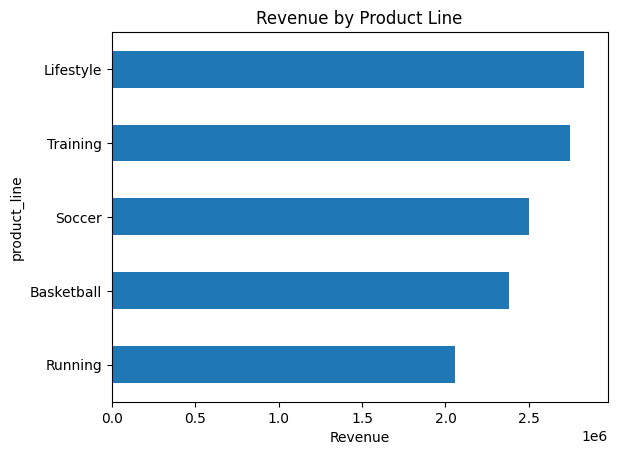

In [ ]:
import matplotlib.pyplot as plt

df.groupby('product_line')['revenue'].sum().sort_values().plot(kind='barh')
plt.title("Revenue by Product Line")
plt.xlabel("Revenue")
plt.show()

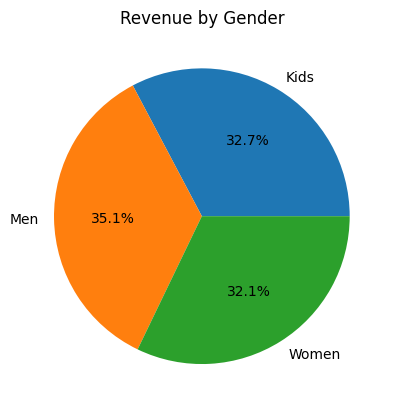

In [ ]:
df.groupby('gender_category')['revenue'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue by Gender")
plt.ylabel("")
plt.show()

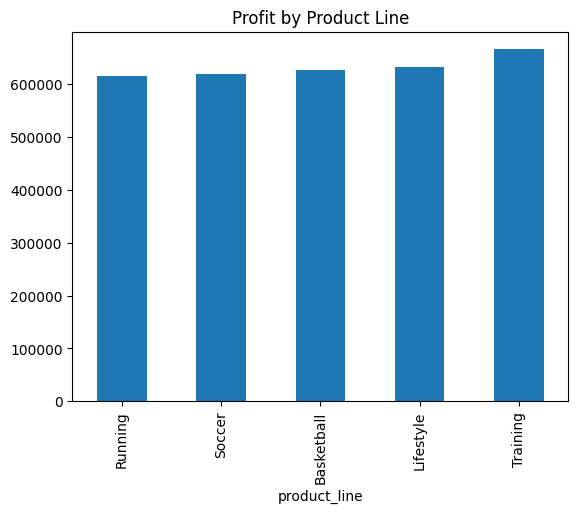

In [ ]:
df.groupby('product_line')['profit'].sum().sort_values().plot(kind='bar')
plt.title("Profit by Product Line")
plt.show()

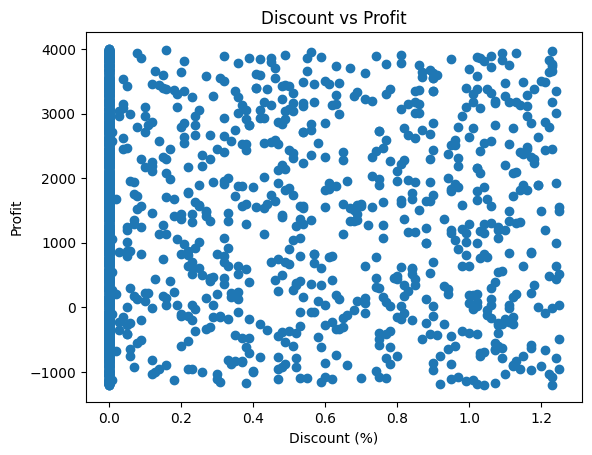

In [ ]:
plt.scatter(df['discount_applied'], df['profit'])
plt.xlabel("Discount (%)")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

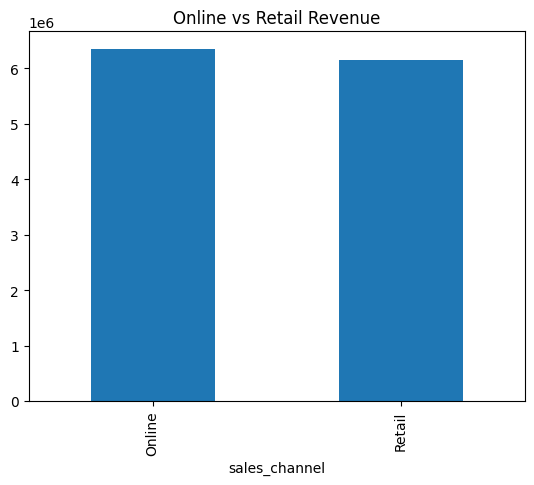

In [ ]:
df.groupby('sales_channel')['revenue'].sum().plot(kind='bar')
plt.title("Online vs Retail Revenue")
plt.show()

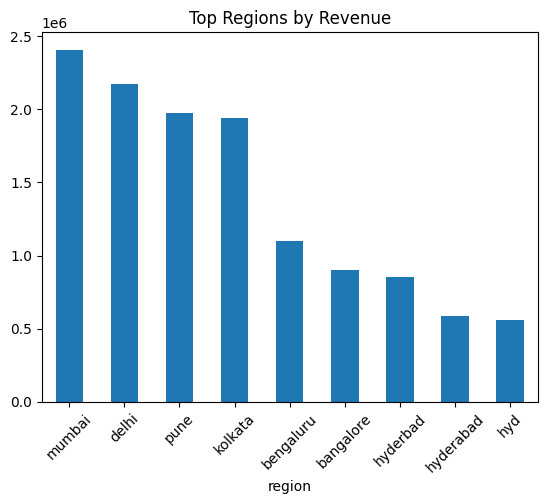

In [ ]:
df.groupby('region')['revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Regions by Revenue")
plt.xticks(rotation=45)
plt.show()

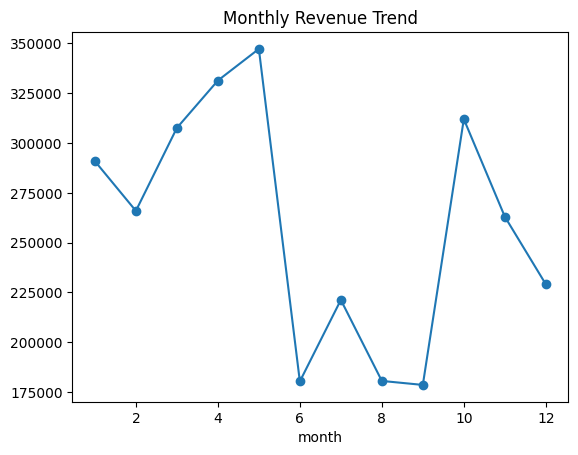

In [ ]:
df['month'] = df['order_date'].dt.month

df.groupby('month')['revenue'].sum().plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.show()

In [ ]:
df.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(5)

,revenue
product_name,
Blazer Mid,762277.171207
ZoomX Invincible,760425.957627
Zoom Freak,754524.003265
SuperRep Go,751383.601019
Flex Trainer,728433.406636


In [ ]:
loss_df = df[df['profit'] < 0]
loss_df.head()

,order_id,gender_category,product_line,product_name,size,units_sold,mrp,discount_applied,revenue,order_date,sales_channel,region,profit,month
0,2000,Kids,Training,SuperRep Go,M,0.0,6110.03,0.47,0.00,2024-03-09,Online,bengaluru,-770.45,3.0
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,0.00,14873.79,2024-07-09,Retail,hyd,-112.53,7.0
14,2014,Women,Running,React Infinity,11,0.0,6110.03,0.00,0.00,2025-04-12,Online,bangalore,-1044.40,4.0
18,2018,Men,Training,Metcon 7,XL,0.0,6110.03,1.17,0.00,NaT,Online,bengaluru,-966.89,NaN
27,2027,Men,Basketball,Zoom Freak,XL,0.0,6110.03,0.22,0.00,NaT,Online,pune,-138.74,NaN


In [ ]:
df[df['discount_applied'] > 50].groupby('product_line')['profit'].mean()

,profit
product_line,


In [ ]:
df.to_csv("nike_cleaned_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("nike_cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>